In [ ]:
import kagglehub

path = kagglehub.dataset_download("fantacher/neu-metal-surface-defects-data")

print("Path to dataset files:", path)

In [ ]:
import shutil
from pathlib import Path

src_path = Path("/root/.cache/kagglehub/datasets/fantacher/neu-metal-surface-defects-data/versions/1")

dst_path = Path("/content/dataset/neu")

if dst_path.exists():
    shutil.rmtree(dst_path)

shutil.copytree(src_path, dst_path)


In [3]:
from pathlib import Path
import os, cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_root = Path("dataset/neu/NEU Metal Surface Defects Data")
train_dir = data_root / "train"
val_dir   = data_root / "valid"
test_dir  = data_root / "test"

classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
print("Classes:", classes)

Classes: ['Crazing', 'Inclusion', 'Patches', 'Pitted', 'Rolled', 'Scratches']


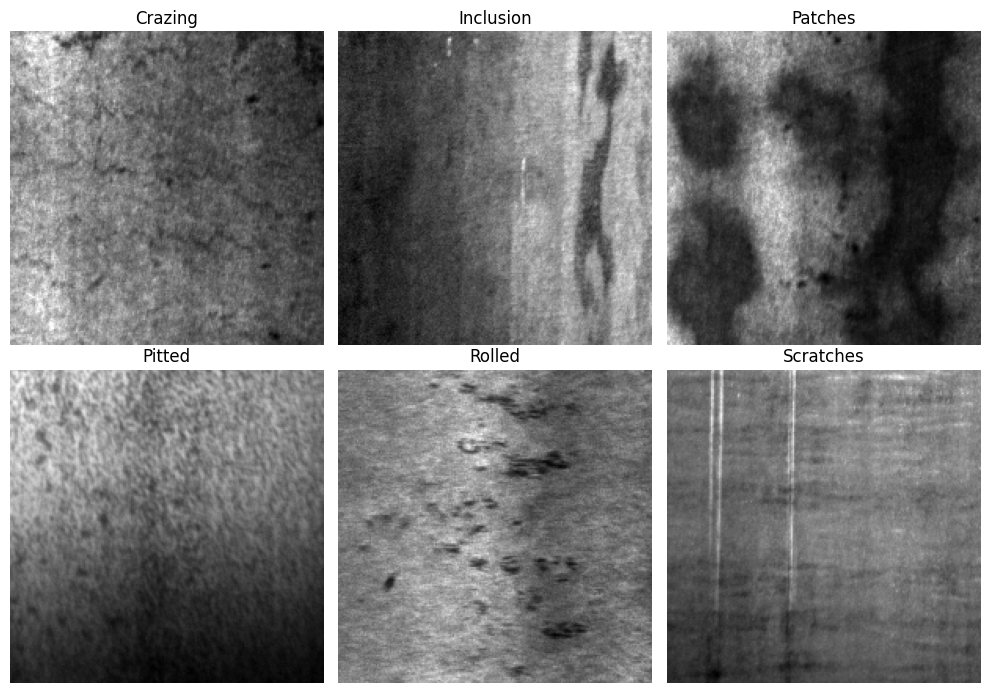

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(10,7))
for ax, cls in zip(axes.ravel(), classes):
    cands = list((train_dir/cls).glob("*.bmp"))
    img = cv2.imread(str(cands[0]), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap="gray")
    ax.set_title(cls)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [5]:
img_size   = (200, 200)
batch_size = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
).flow_from_directory(
    str(train_dir),
    target_size=img_size,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=True
)

val_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    str(val_dir),
    target_size=img_size,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False
)

test_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    str(test_dir),
    target_size=img_size,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False
)

inv_map = {v: k for k, v in train_gen.class_indices.items()}
print("Class indexes:", train_gen.class_indices)

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Class indexes: {'Crazing': 0, 'Inclusion': 1, 'Patches': 2, 'Pitted': 3, 'Rolled': 4, 'Scratches': 5}


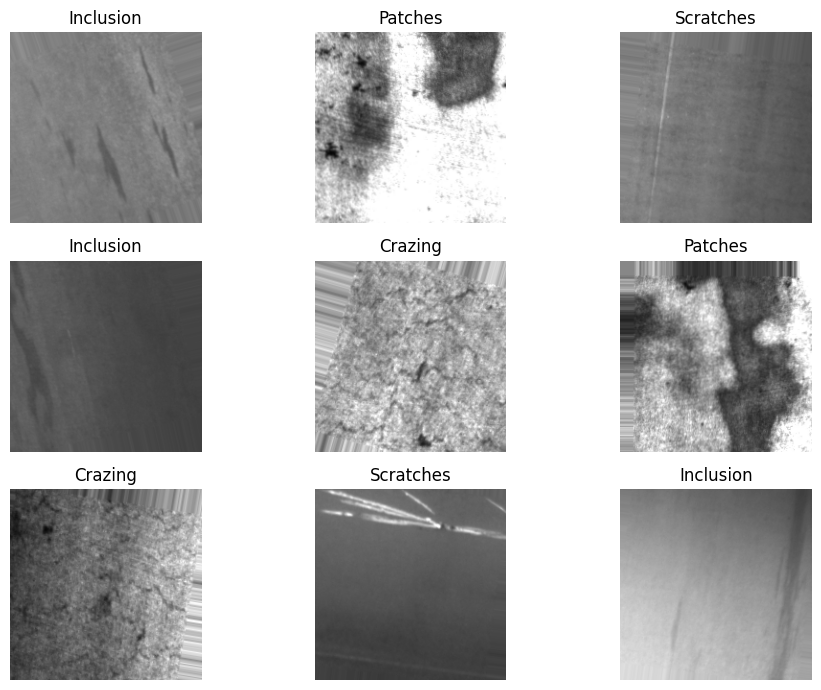

In [6]:
imgs, labs = next(train_gen)

plt.figure(figsize=(10,7))
for i in range(9):
    ax = plt.subplot(3,3,i+1)
    ax.imshow(imgs[i])
    cls_id = int(np.argmax(labs[i]))
    ax.set_title(inv_map[cls_id])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(200,200,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,761,286 (33.42 MB)

 Trainable params: 8,761,286 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 30s 427ms/step - accuracy: 0.1765 - loss: 2.0481 - val_accuracy: 0.3333 - val_loss: 1.5771
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 297ms/step - accuracy: 0.3121 - loss: 1.5933 - val_accuracy: 0.5417 - val_loss: 1.0583
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 16s 299ms/step - accuracy: 0.3511 - loss: 1.5563 - val_accuracy: 0.5556 - val_loss: 1.2488
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 17s 317ms/step - accuracy: 0.5569 - loss: 1.1754 - val_accuracy: 0.8333 - val_loss: 0.6526
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 296ms/step - accuracy: 0.6719 - loss: 0.8620 - val_accuracy: 0.8611 - val_loss: 0.5117
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 297ms/step - accuracy: 0.8068 - loss: 0.6117 - val_accuracy: 0.9306 - val_loss: 0.2958
Epoch 7/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 16s 306ms/step - accuracy: 0.8240 - loss: 0.5765 - val_accuracy: 0.8889 - val_loss: 0.3599
Epoch 8/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 16s 300ms/step - accuracy: 0.8403 - loss: 0.4812 - val_accu

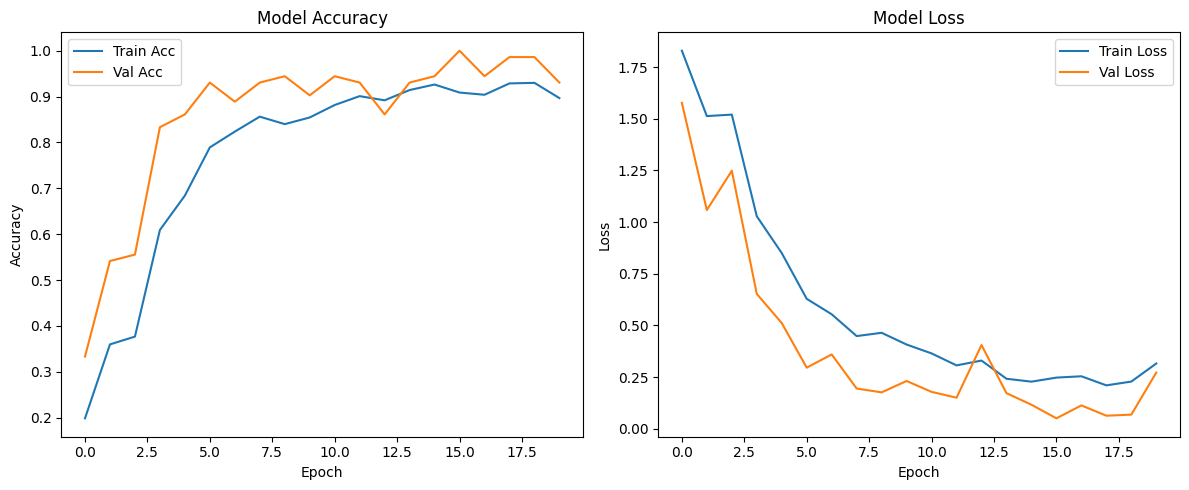

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (200, 200)
batch_size = 16

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True
).flow_from_directory(
    str(train_dir),
    target_size=img_size,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    str(val_dir),
    target_size=img_size,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(200,200,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')
])

In [15]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history18 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20
)

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 26s 194ms/step - accuracy: 0.1883 - loss: 1.8508 - val_accuracy: 0.4167 - val_loss: 1.4085
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 157ms/step - accuracy: 0.3318 - loss: 1.5443 - val_accuracy: 0.4444 - val_loss: 1.4952
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 155ms/step - accuracy: 0.4079 - loss: 1.4125 - val_accuracy: 0.4028 - val_loss: 1.3521
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 17s 165ms/step - accuracy: 0.5038 - loss: 1.3088 - val_accuracy: 0.3750 - val_loss: 1.5239
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 17s 158ms/step - accuracy: 0.4778 - loss: 1.3219 - val_accuracy: 0.6111 - val_loss: 1.5386
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - accuracy: 0.5183 - loss: 1.2394 - val_accuracy: 0.5556 - val_loss: 1.0294
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 17s 164ms/step - accuracy: 0.5839 - loss: 1.0972 - val_accuracy: 0.6250 - val_loss: 0.8955
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 157ms/step - accuracy: 0.6483 - loss: 0

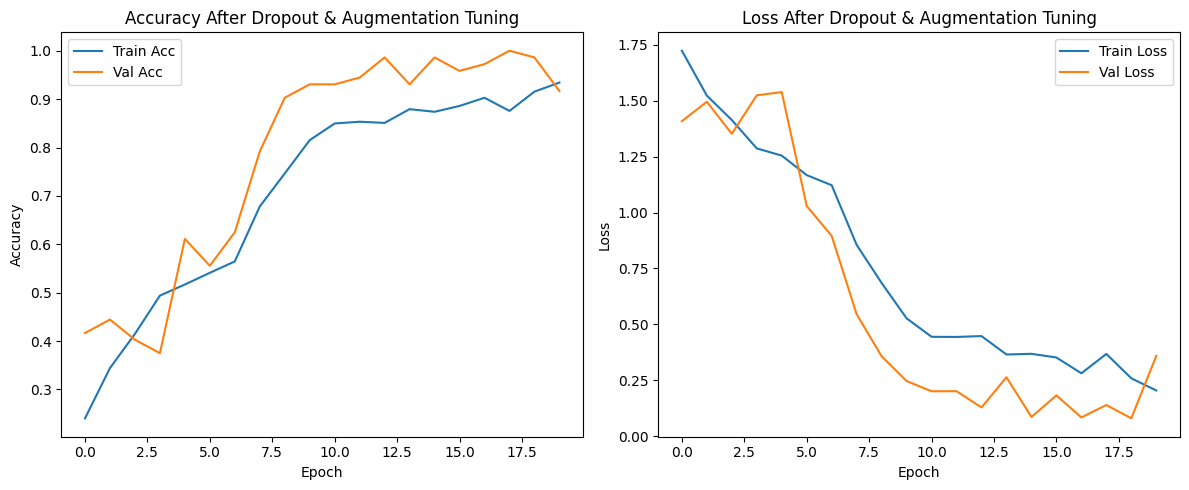

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history18.history['accuracy'], label='Train Acc')
plt.plot(history18.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy After Dropout & Augmentation Tuning')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history18.history['loss'], label='Train Loss')
plt.plot(history18.history['val_loss'], label='Val Loss')
plt.title('Loss After Dropout & Augmentation Tuning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

In [19]:
epochs = 40

history19 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 153ms/step - accuracy: 0.9345 - loss: 0.2077 - val_accuracy: 0.9722 - val_loss: 0.1442 - learning_rate: 0.0010
Epoch 2/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 153ms/step - accuracy: 0.9414 - loss: 0.1967 - val_accuracy: 1.0000 - val_loss: 0.0357 - learning_rate: 0.0010
Epoch 3/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 17s 160ms/step - accuracy: 0.9155 - loss: 0.2354 - val_accuracy: 1.0000 - val_loss: 0.0427 - learning_rate: 0.0010
Epoch 4/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 20s 151ms/step - accuracy: 0.9154 - loss: 0.2441 - val_accuracy: 1.0000 - val_loss: 0.0416 - learning_rate: 0.0010
Epoch 5/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9393 - loss: 0.1983
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 157ms/step - accuracy: 0.9393 - loss: 0.1984 - val_accuracy: 1.0000 - val_loss: 0.0677 - learning_rate: 0.0010
Epoch 6/40
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 152ms/step - accuracy: 0.94

Test Loss: 0.0783  |  Test Acc: 0.9861


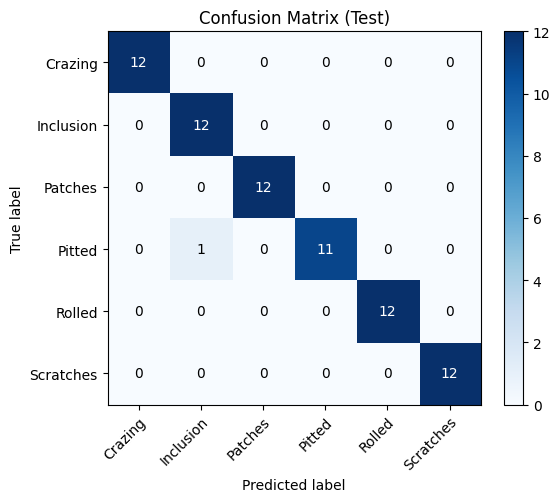

              precision    recall  f1-score   support

     Crazing     1.0000    1.0000    1.0000        12
   Inclusion     0.9231    1.0000    0.9600        12
     Patches     1.0000    1.0000    1.0000        12
      Pitted     1.0000    0.9167    0.9565        12
      Rolled     1.0000    1.0000    1.0000        12
   Scratches     1.0000    1.0000    1.0000        12

    accuracy                         0.9861        72
   macro avg     0.9872    0.9861    0.9861        72
weighted avg     0.9872    0.9861    0.9861        72



In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Test Loss: {test_loss:.4f}  |  Test Acc: {test_acc:.4f}")

y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

y_pred_probs = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(len(class_names)),
    yticks=np.arange(len(class_names)),
    xticklabels=class_names, yticklabels=class_names,
    ylabel='True label', xlabel='Predicted label',
    title='Confusion Matrix (Test)'
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


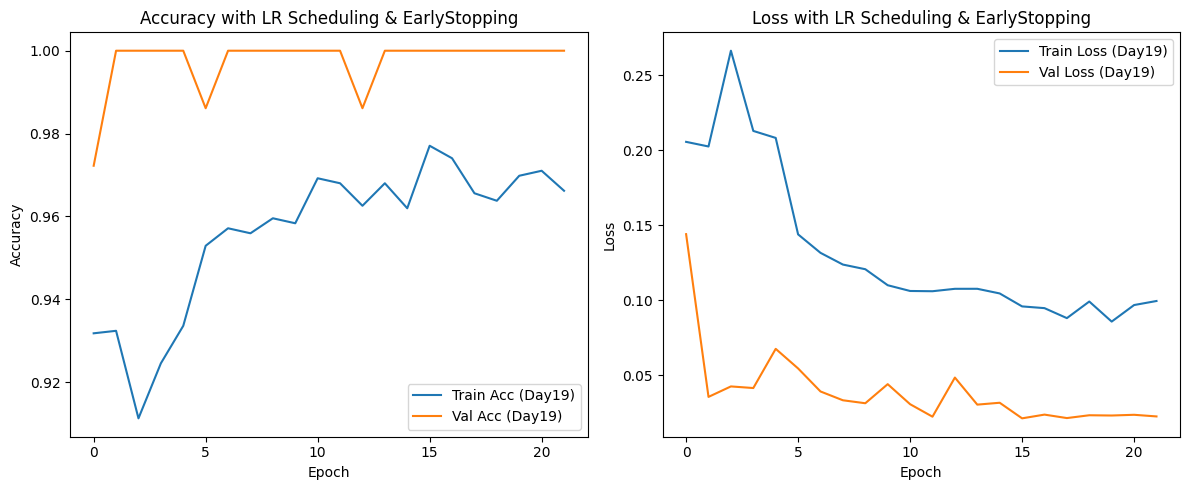

In [21]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history19.history['accuracy'], label='Train Acc (Day19)')
plt.plot(history19.history['val_accuracy'], label='Val Acc (Day19)')
plt.title('Accuracy with LR Scheduling & EarlyStopping')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history19.history['loss'], label='Train Loss (Day19)')
plt.plot(history19.history['val_loss'], label='Val Loss (Day19)')
plt.title('Loss with LR Scheduling & EarlyStopping')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout(); plt.show()

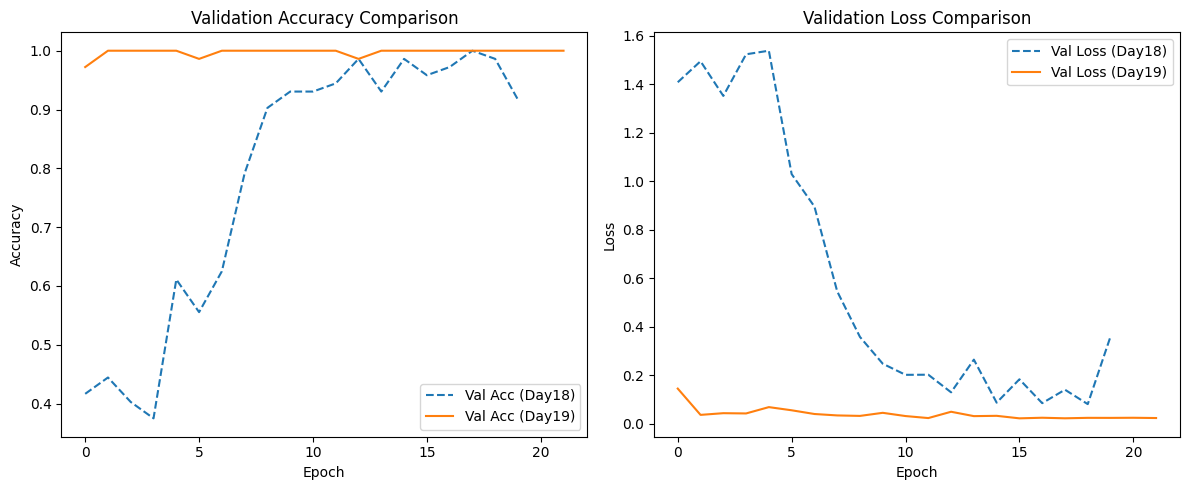

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

hist18 = pd.read_csv('training_history18.csv')
hist19 = pd.read_csv('training_history19.csv')

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(hist18['val_accuracy'], label='Val Acc (Day18)', linestyle='--')
plt.plot(hist19['val_accuracy'], label='Val Acc (Day19)', linestyle='-')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist18['val_loss'], label='Val Loss (Day18)', linestyle='--')
plt.plot(hist19['val_loss'], label='Val Loss (Day19)', linestyle='-')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


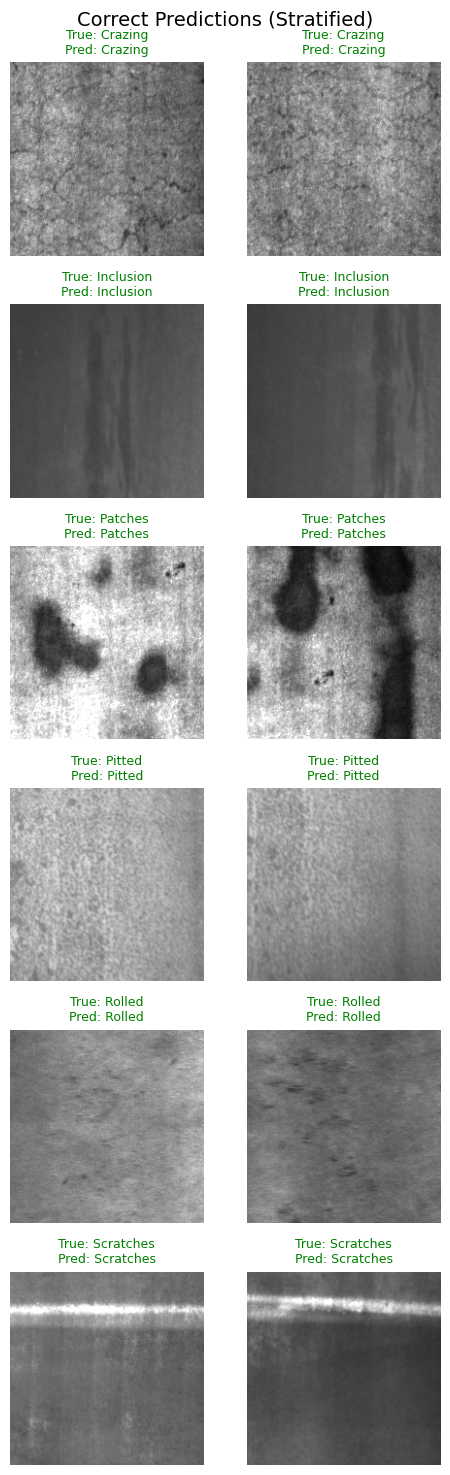

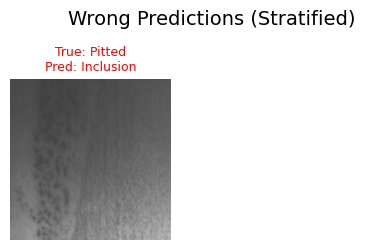

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array


def load_display_image(gen, sample_index):
    p = gen.filepaths[sample_index]
    img = load_img(p, target_size=gen.target_size, color_mode='rgb')
    x = img_to_array(img) / 255.0
    return x

n_classes = len(class_names)
true_idx_by_class   = {c: np.where(y_true == c)[0] for c in range(n_classes)}
correct_idx_by_class = {c: np.where((y_true == c) & (y_pred == c))[0] for c in range(n_classes)}
wrong_idx_by_class   = {c: np.where((y_true == c) & (y_pred != c))[0] for c in range(n_classes)}

n_per_class_correct = 2
n_per_class_wrong   = 2

def stratified_pick(idx_dict, n_per_class):
    picks = []
    for c in range(n_classes):
        idxs = idx_dict[c]
        if len(idxs) == 0:
            continue
        take = min(n_per_class, len(idxs))
        chosen = np.random.choice(idxs, size=take, replace=False)
        picks.extend(chosen.tolist())
    return picks

correct_picks = stratified_pick(correct_idx_by_class, n_per_class_correct)
wrong_picks   = stratified_pick(wrong_idx_by_class,   n_per_class_wrong)

if len(wrong_picks) < n_classes:
    global_wrong = np.where(y_true != y_pred)[0]
    need = n_classes - len(wrong_picks)
    if len(global_wrong) > 0 and need > 0:
        extras = [i for i in global_wrong if i not in wrong_picks]
        if len(extras) > 0:
            add = min(need, len(extras))
            wrong_picks.extend(np.random.choice(extras, size=add, replace=False).tolist())

def plot_indices(indices, title, color):
    if len(indices) == 0:
        print(f"No samples to show for: {title}")
        return
    max_show = min(len(indices), 12)
    cols = 2
    rows = int(np.ceil(max_show / cols))
    plt.figure(figsize=(2.5*cols, 2.5*rows))
    for k, sample_index in enumerate(indices[:max_show]):
        img = load_display_image(test_gen, sample_index)
        plt.subplot(rows, cols, k+1)
        plt.imshow(img)
        t = class_names[int(y_true[sample_index])]
        p = class_names[int(y_pred[sample_index])]
        plt.title(f"True: {t}\nPred: {p}", color=color, fontsize=9)
        plt.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_indices(correct_picks, "Correct Predictions (Stratified)", "green")
plot_indices(wrong_picks,   "Wrong Predictions (Stratified)",   "red")

In [36]:
import pandas as pd

summary = pd.DataFrame({
    'Model': ['Day18', 'Day19'],
    'Best Val Acc': [hist18['val_accuracy'].max(), hist19['val_accuracy'].max()],
    'Best Val Loss': [hist18['val_loss'].min(), hist19['val_loss'].min()],
    'Test Accuracy': [0.986, 0.9861],
    'Epochs Trained': [len(hist18), len(hist19)]
})

print(summary)

   Model  Best Val Acc  Best Val Loss  Test Accuracy  Epochs Trained
0  Day18           1.0       0.080044         0.9860              20
1  Day19           1.0       0.021414         0.9861              22
